In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("data/Reviews.csv")

df = df.sample(n=20000, random_state=42)

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
165256,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...
231465,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...
427827,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...
433954,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin..."
70260,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...


 Con esta linea borramos las reseñas con valor neutro

In [6]:
df = df[df['Score'] != 3]

Creamos la variable objeto

In [7]:
df['sentiment'] = df['Score'].apply(lambda x: 1 if x >= 4 else 0)

df['sentiment'].value_counts()

sentiment
1    15595
0     2886
Name: count, dtype: int64

El dataset está desbalanceado, lo que puede sesgar el modelo hacia la clase mayoritaria y afectar la capacidad de detectar reseñas negativas.

In [8]:
df['sentiment'].value_counts(normalize=True)

sentiment
1    0.84384
0    0.15616
Name: proportion, dtype: float64

In [9]:
df['Text'].iloc[0]

'Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They\'re crunchy and true to the texture of the other "real" cookies that aren\'t gluten-free.  Some might think that the filling makes them a bit too sweet, but for me that just means I\'ve satisfied my sweet tooth sooner!  The chocolate version from Glutino is just as good and has a true "chocolatey" taste - something that isn\'t there with the other gluten-free brands out there.'

Las reseñas presentan texto en lenguaje natural, con longitud variable y presencia de caracteres especiales. Esto hace necesario un proceso de limpieza y normalización antes de aplicar técnicas de vectorización

In [10]:
df['Text'].str.len().describe()

count    18481.000000
mean       430.727666
std        443.695689
min         35.000000
25%        178.000000
50%        297.000000
75%        518.000000
max       9177.000000
Name: Text, dtype: float64

La distribución de longitudes muestra presencia de outliers significativos, lo que puede afectar el procesamiento y aumentar la dimensionalidad del modelo

In [11]:
df = df[df['Text'].str.len() < 2000]

df['Text'].str.len().describe()

count    18261.000000
mean       399.847544
std        319.924368
min         35.000000
25%        177.000000
50%        293.000000
75%        506.000000
max       1998.000000
Name: Text, dtype: float64

Se identificaron outliers en la longitud de las reseñas, alcanzando valores superiores a 9000 caracteres. Se decidió limitar la longitud a 2000 caracteres para reducir ruido y mejorar la eficiencia del modelo

In [12]:
df['Text'].head(5)

165256    Having tried a couple of other brands of glute...
231465    My cat loves these treats. If ever I can't fin...
433954    First there was Frosted Mini-Wheats, in origin...
70260     and I want to congratulate the graphic artist ...
49866     Please add more Pineapple flavor to your packa...
Name: Text, dtype: str

In [13]:
df['Text'].iloc[0]

'Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They\'re crunchy and true to the texture of the other "real" cookies that aren\'t gluten-free.  Some might think that the filling makes them a bit too sweet, but for me that just means I\'ve satisfied my sweet tooth sooner!  The chocolate version from Glutino is just as good and has a true "chocolatey" taste - something that isn\'t there with the other gluten-free brands out there.'

Las reseñas contienen texto en lenguaje natural con presencia de mayúsculas, puntuación, contracciones y caracteres especiales, lo que hace necesario aplicar un proceso de limpieza y normalización antes de su vectorización.

In [14]:
import re

def clean_text(text):

    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+', '', text)
    
    text = re.sub(r'[^a-z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
  
    return text

Agregamos una funcion de limpieza

In [15]:
df['clean_text'] = df['Text'].apply(clean_text)

In [16]:
df[['Text', 'clean_text']].head(3)

,Text,clean_text
165256,Having tried a couple of other brands of glute...,having tried a couple of other brands of glute...
231465,My cat loves these treats. If ever I can't fin...,my cat loves these treats if ever i cant find ...
433954,"First there was Frosted Mini-Wheats, in origin...",first there was frosted miniwheats in original...


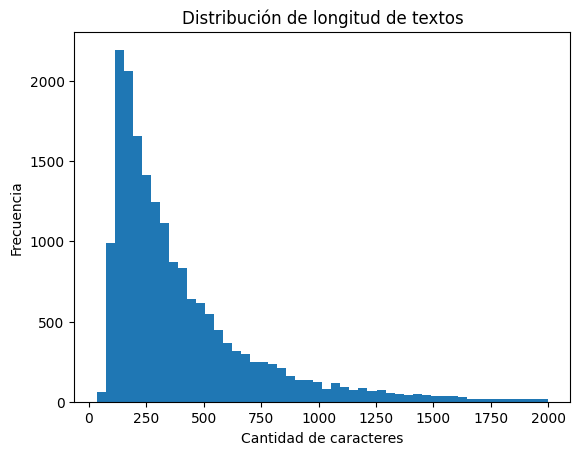

In [44]:
df['text_length'] = df['Text'].apply(len)

import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['text_length'], bins=50)

plt.title("Distribución de longitud de textos")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")

plt.show()

Se observa una alta variabilidad en la longitud de los textos, lo cual puede influir en el rendimiento del modelo. Textos muy largos pueden introducir ruido, mientras que textos muy cortos pueden no contener suficiente información para una correcta clasificación.

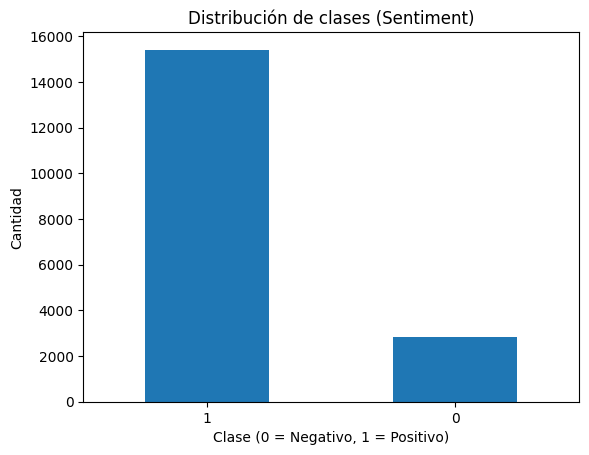

In [41]:
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')

plt.title("Distribución de clases (Sentiment)")
plt.xlabel("Clase (0 = Negativo, 1 = Positivo)")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)

plt.show()

Se observa un claro desbalance en las clases, con una predominancia de reseñas positivas sobre negativas. Este desbalance puede afectar el desempeño del modelo, favoreciendo la predicción de la clase mayoritaria.

Esto demuestra que la limpieza mediante Regex elimina ruido, pero también puede afectar el significado del texto, especialmente en casos de negaciones y énfasis, lo que puede impactar en la capacidad del modelo para interpretar correctamente el sentimiento

In [17]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ger\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ger\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [42]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [word for word, freq in common_words]
freqs = [freq for word, freq in common_words]

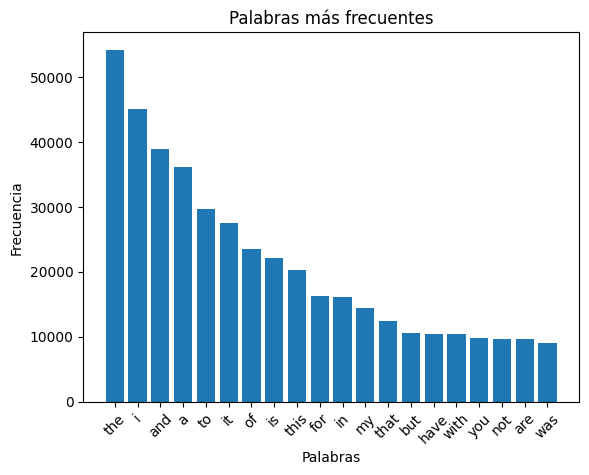

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(words, freqs)
plt.xticks(rotation=45)

plt.title("Palabras más frecuentes")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")

plt.show()

Las palabras más frecuentes reflejan términos comunes del lenguaje cotidiano, muchos de ellos con poca carga semántica relevante. Esto refuerza la necesidad de aplicar técnicas como eliminación de stopwords y TF-IDF para mejorar la representación del texto.

In [18]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(df['clean_text'].iloc[0])
tokens

['having',
 'tried',
 'a',
 'couple',
 'of',
 'other',
 'brands',
 'of',
 'glutenfree',
 'sandwich',
 'cookies',
 'these',
 'are',
 'the',
 'best',
 'of',
 'the',
 'bunch',
 'theyre',
 'crunchy',
 'and',
 'true',
 'to',
 'the',
 'texture',
 'of',
 'the',
 'other',
 'real',
 'cookies',
 'that',
 'arent',
 'glutenfree',
 'some',
 'might',
 'think',
 'that',
 'the',
 'filling',
 'makes',
 'them',
 'a',
 'bit',
 'too',
 'sweet',
 'but',
 'for',
 'me',
 'that',
 'just',
 'means',
 'ive',
 'satisfied',
 'my',
 'sweet',
 'tooth',
 'sooner',
 'the',
 'chocolate',
 'version',
 'from',
 'glutino',
 'is',
 'just',
 'as',
 'good',
 'and',
 'has',
 'a',
 'true',
 'chocolatey',
 'taste',
 'something',
 'that',
 'isnt',
 'there',
 'with',
 'the',
 'other',
 'glutenfree',
 'brands',
 'out',
 'there']

Detectamos stopwords

In [19]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ger\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Eliminamos las stopwords

In [20]:
tokens_clean = [word for word in tokens if word not in stop_words]
tokens_clean

['tried',
 'couple',
 'brands',
 'glutenfree',
 'sandwich',
 'cookies',
 'best',
 'bunch',
 'theyre',
 'crunchy',
 'true',
 'texture',
 'real',
 'cookies',
 'arent',
 'glutenfree',
 'might',
 'think',
 'filling',
 'makes',
 'bit',
 'sweet',
 'means',
 'ive',
 'satisfied',
 'sweet',
 'tooth',
 'sooner',
 'chocolate',
 'version',
 'glutino',
 'good',
 'true',
 'chocolatey',
 'taste',
 'something',
 'isnt',
 'glutenfree',
 'brands']

In [21]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Ger\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Ger\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [22]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

tokens_lemma_nltk = [lemmatizer.lemmatize(word) for word in tokens_clean]

tokens_lemma_nltk

['tried',
 'couple',
 'brand',
 'glutenfree',
 'sandwich',
 'cooky',
 'best',
 'bunch',
 'theyre',
 'crunchy',
 'true',
 'texture',
 'real',
 'cooky',
 'arent',
 'glutenfree',
 'might',
 'think',
 'filling',
 'make',
 'bit',
 'sweet',
 'mean',
 'ive',
 'satisfied',
 'sweet',
 'tooth',
 'sooner',
 'chocolate',
 'version',
 'glutino',
 'good',
 'true',
 'chocolatey',
 'taste',
 'something',
 'isnt',
 'glutenfree',
 'brand']

In [23]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp(df['clean_text'].iloc[0])

tokens_lemma_spacy = [token.lemma_ for token in doc]

tokens_lemma_spacy

['having',
 'try',
 'a',
 'couple',
 'of',
 'other',
 'brand',
 'of',
 'glutenfree',
 'sandwich',
 'cooky',
 'these',
 'be',
 'the',
 'good',
 'of',
 'the',
 'bunch',
 'they',
 're',
 'crunchy',
 'and',
 'true',
 'to',
 'the',
 'texture',
 'of',
 'the',
 'other',
 'real',
 'cooky',
 'that',
 'be',
 'not',
 'glutenfree',
 'some',
 'might',
 'think',
 'that',
 'the',
 'filling',
 'make',
 'they',
 'a',
 'bit',
 'too',
 'sweet',
 'but',
 'for',
 'I',
 'that',
 'just',
 'mean',
 'I',
 've',
 'satisfy',
 'my',
 'sweet',
 'tooth',
 'soon',
 'the',
 'chocolate',
 'version',
 'from',
 'glutino',
 'be',
 'just',
 'as',
 'good',
 'and',
 'have',
 'a',
 'true',
 'chocolatey',
 'taste',
 'something',
 'that',
 'be',
 'not',
 'there',
 'with',
 'the',
 'other',
 'glutenfree',
 'brand',
 'out',
 'there']

Se comparó la lematización utilizando NLTK y spaCy.

Se observó que spaCy presenta mejores resultados debido a su capacidad de analizar el contexto gramatical (POS tagging), permitiendo transformar palabras como "best" en "good" o "tried" en "try".

Por otro lado, NLTK aplica reglas más simples, lo que puede generar resultados menos precisos al no considerar el contexto de la palabra dentro de la oración.

En conclusión, spaCy ofrece una lematización más precisa y adecuada para tareas de NLP.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

El texto debe ser transformado a formato numérico ya que los modelos de machine learning operan sobre datos numéricos. Técnicas como TF-IDF permiten representar la importancia relativa de cada palabra dentro de un documento, facilitando la detección de patrones para la clasificación

In [25]:
vectorizer = TfidfVectorizer(max_features=5000)

In [26]:
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In [27]:
X.shape

(18261, 5000)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
X_train.shape, X_test.shape

((14608, 5000), (3653, 5000))

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim

In [31]:
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [32]:
class TextClassifier(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifier, self).__init__()
        
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [33]:
input_dim = X_train.shape[1]

model = TextClassifier(input_dim)

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
epochs = 10

for epoch in range(epochs):
    model.train()
    
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.848394513130188
Epoch 2, Loss: 0.7038558125495911
Epoch 3, Loss: 0.6102304458618164
Epoch 4, Loss: 0.5357245802879333
Epoch 5, Loss: 0.47507256269454956
Epoch 6, Loss: 0.4281429648399353
Epoch 7, Loss: 0.38221192359924316
Epoch 8, Loss: 0.3463456928730011
Epoch 9, Loss: 0.31437844038009644
Epoch 10, Loss: 0.28545600175857544


In [36]:
model.eval()

with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)
    
    accuracy = (predicted == y_test_tensor).sum().item() / len(y_test_tensor)
    
print(f"Accuracy: {accuracy}")

Accuracy: 0.8546400218998084


El accuracy obtenido (~85%) es similar a la proporción de la clase mayoritaria, lo que sugiere que el modelo podría estar sesgado hacia predecir mayormente la clase positiva.

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test_tensor, predicted))

              precision    recall  f1-score   support

           0       0.99      0.12      0.21       599
           1       0.85      1.00      0.92      3054

    accuracy                           0.85      3653
   macro avg       0.92      0.56      0.56      3653
weighted avg       0.87      0.85      0.80      3653



Si bien el modelo alcanza una accuracy de aproximadamente 85%, el análisis de métricas más detalladas revela un fuerte sesgo hacia la clase mayoritaria.

El recall para la clase negativa es de apenas 0.12, lo que indica que el modelo no logra identificar correctamente la mayoría de las reseñas negativas.

Esto sugiere que el modelo tiende a predecir predominantemente la clase positiva, probablemente debido al desbalance presente en el dataset.

Por lo tanto, el accuracy no resulta una métrica suficiente para evaluar el desempeño en este caso.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [39]:
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.long)

In [40]:
epochs = 50
patience = 5

best_loss = float("inf")
counter = 0

for epoch in range(epochs):
    
    # ---- TRAIN ----
    model.train()
    
    outputs = model(X_train_tensor)
    train_loss = criterion(outputs, y_train_tensor)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    # ---- VALIDATION ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
    
    print(f"Epoch {epoch+1} | Train Loss: {train_loss.item()} | Val Loss: {val_loss.item()}")
    
    # ---- EARLY STOPPING ----
    if val_loss.item() < best_loss:
        best_loss = val_loss.item()
        counter = 0
    else:
        counter += 1
    
    if counter >= patience:
        print("Early stopping activado")
        break

Epoch 1 | Train Loss: 0.2598179578781128 | Val Loss: 0.6606155037879944
Epoch 2 | Train Loss: 0.23781147599220276 | Val Loss: 0.6575471758842468
Epoch 3 | Train Loss: 0.21840405464172363 | Val Loss: 0.654351532459259
Epoch 4 | Train Loss: 0.20243515074253082 | Val Loss: 0.6509799361228943
Epoch 5 | Train Loss: 0.186604306101799 | Val Loss: 0.6473732590675354
Epoch 6 | Train Loss: 0.17397232353687286 | Val Loss: 0.6434643864631653
Epoch 7 | Train Loss: 0.1640026867389679 | Val Loss: 0.6393101215362549
Epoch 8 | Train Loss: 0.15197350084781647 | Val Loss: 0.634918749332428
Epoch 9 | Train Loss: 0.14505518972873688 | Val Loss: 0.6303361058235168
Epoch 10 | Train Loss: 0.13509684801101685 | Val Loss: 0.6255661249160767
Epoch 11 | Train Loss: 0.12954746186733246 | Val Loss: 0.6205957531929016
Epoch 12 | Train Loss: 0.12199766933917999 | Val Loss: 0.6155533194541931
Epoch 13 | Train Loss: 0.11771432310342789 | Val Loss: 0.6104434728622437
Epoch 14 | Train Loss: 0.11171367019414902 | Val Loss

Se implementó una estrategia de Early Stopping con una paciencia de 5 épocas, deteniendo el entrenamiento cuando la pérdida de validación dejó de mejorar.

Esto permite evitar el sobreajuste (overfitting), asegurando que el modelo no continúe aprendiendo patrones específicos del conjunto de entrenamiento que no generalizan a nuevos datos.

## CONCLUSIÓN FINAL
El modelo desarrollado logró alcanzar una accuracy aproximada del 85%, mostrando una mejora sostenida tanto en la pérdida de entrenamiento como de validación.

Sin embargo, el análisis detallado mediante métricas como precision, recall y F1-score evidenció un fuerte sesgo hacia la clase mayoritaria (reseñas positivas), con un recall muy bajo para la clase negativa.

Esto indica que, a pesar del buen desempeño general en términos de accuracy, el modelo no logra capturar adecuadamente los casos minoritarios, lo cual es una limitación importante en escenarios reales.

Como mejoras futuras, se podrían aplicar técnicas de balanceo de clases, ajuste de hiperparámetros o modelos más avanzados para lograr una mejor capacidad de generalización y un desempeño más equilibrado entre clases.